In [1]:
from __future__ import print_function
import sys, os
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

import ROOT
from ROOT import gROOT, gStyle, gDirectory, gPad

import filepath 
import portROOT2pd
from pdgid import pdgid_dict
import plot_utils
import constants

geometry = "stm_pawel"
tags = ["Ele", "Mu"]
pklname = geometry+".pkl"


In [2]:
df = pd.DataFrame()
for tag in tags:
    fileList_ = filepath.getrootlist(geometry, tag)
    df_ = portROOT2pd.PortToDF(geometry, tag, fileList_, True, 101)
    df = pd.concat([df,df_], ignore_index=True)

print("VDs:", np.sort(df['virtualdetectorId'].unique()))
df = df.query("r<100").reset_index(drop=True)

with open(pklname, 'wb') as f:
    pickle.dump(df, f)

Opening /exp/mu2e/data/users/yongyiwu/stm_pawel/sim.plesniak.Stage1.Ele1.root
12516645  entries are found
1  entries are collected
50001  entries are collected
100001  entries are collected
150001  entries are collected
200001  entries are collected
250001  entries are collected
300001  entries are collected
350001  entries are collected
Opening /exp/mu2e/data/users/yongyiwu/stm_pawel/sim.plesniak.Stage1.Ele2.root
7666207  entries are found
400001  entries are collected
450001  entries are collected
500001  entries are collected
550001  entries are collected
Opening /exp/mu2e/data/users/yongyiwu/stm_pawel/sim.plesniak.Stage1.Mu1.root
1848972  entries are found
1  entries are collected
Opening /exp/mu2e/data/users/yongyiwu/stm_pawel/sim.plesniak.Stage1.Mu2.root
6123516  entries are found
50001  entries are collected
100001  entries are collected
150001  entries are collected
Opening /exp/mu2e/data/users/yongyiwu/stm_pawel/sim.plesniak.Stage1.Mu3.root
27944  entries are found
200001  ent

In [3]:
with open(pklname, 'rb') as f:
    df = pickle.load(f)

In [4]:
print("z coordinates of events:", np.sort(df['z'].unique()))
print("weights:", np.sort(df['weight'].unique()))
print("x range: [%.3lf, %.3lf]"%(np.min(df['x'].unique()),np.max(df['x'].unique())))
print("y range: [%.3lf, %.3lf]"%(np.min(df['y'].unique()),np.max(df['y'].unique())))
print("r range: [%.3lf, %.3lf]"%(np.min(df['r'].unique()),np.max(df['r'].unique())))

display(df)

z coordinates of events: [40300.98 40301.  ]
weights: [0.15257389 5.26980298]
x range: [-99.993, 99.983]
y range: [-99.962, 99.975]
r range: [0.074, 100.000]


,tag,time,virtualdetectorId,pdgId,x,y,z,E,r,weight
0,Ele,1.879672e+02,101,22,-85.992097,36.475965,40300.98,418.868157,93.408440,5.269803
1,Ele,2.382152e+02,101,11,-22.779813,3.846906,40300.98,7519.620238,23.102350,5.269803
2,Ele,2.382302e+02,101,22,-22.657765,4.465954,40301.00,1205.558759,23.093702,5.269803
3,Ele,2.382509e+02,101,22,-32.150750,1.455367,40301.00,879.250790,32.183674,5.269803
4,Ele,2.382339e+02,101,22,-21.720568,5.817837,40301.00,177.297948,22.486224,5.269803
...,...,...,...,...,...,...,...,...,...,...
204364,Mu,1.125086e+11,101,22,-70.708518,-63.130189,40300.98,47.220666,94.789848,0.152574
204365,Mu,1.829206e+02,101,22,56.760207,7.712590,40300.98,235.675366,57.281804,0.152574
204366,Mu,1.875128e+02,101,22,-27.718722,-70.543434,40300.98,319.213274,75.793823,0.152574
204367,Mu,2.026776e+02,101,22,-54.578358,11.832440,40300.98,519.011903,55.846251,0.152574



$e^{+}$ from Ele:  366
$e^{-}$ from Ele:  2658
$\gamma$ from Ele:  143524
$n$ from Ele:  568

$e^{+}$ from Mu:  132
$e^{-}$ from Mu:  987
$\gamma$ from Mu:  54981


/exp/mu2e/data/users/yongyiwu/stm_analysis/plot_utils.py:20: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(4,3))


$n$ from Mu:  1153


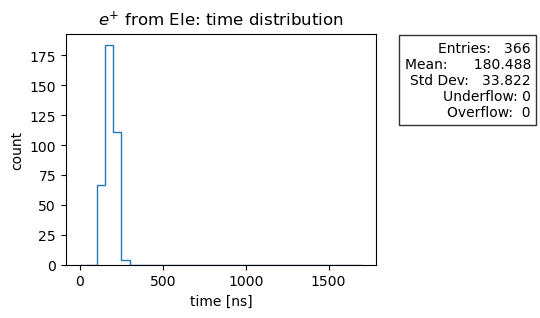

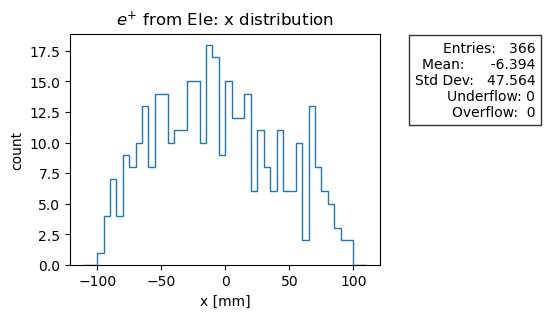

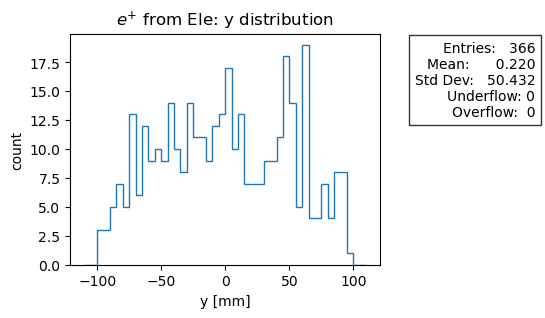

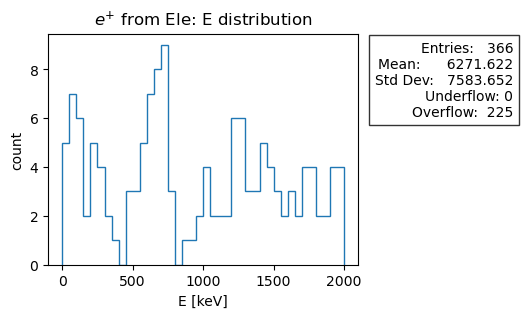

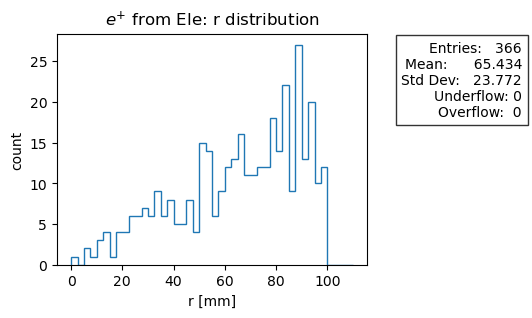

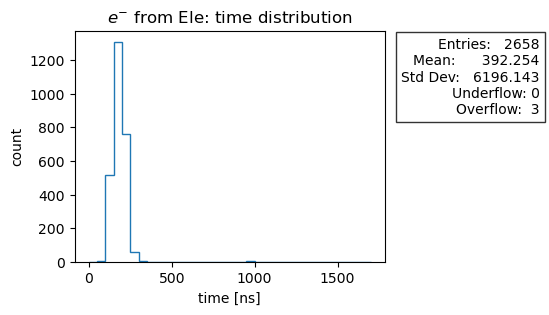

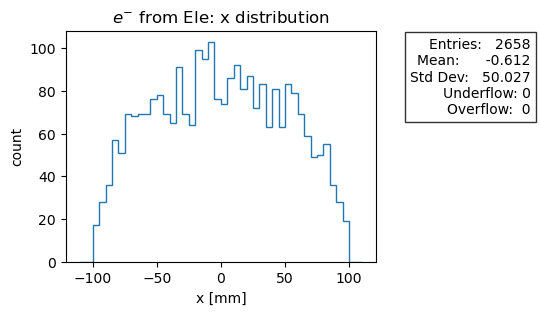

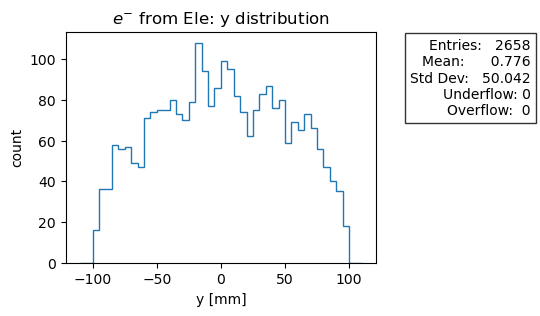

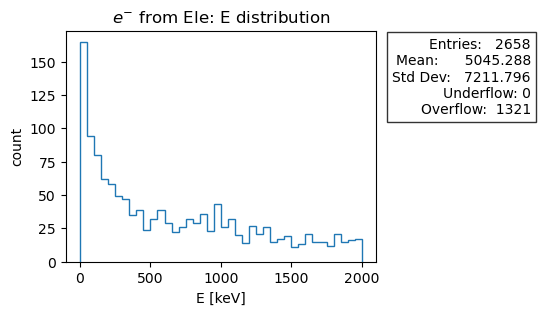

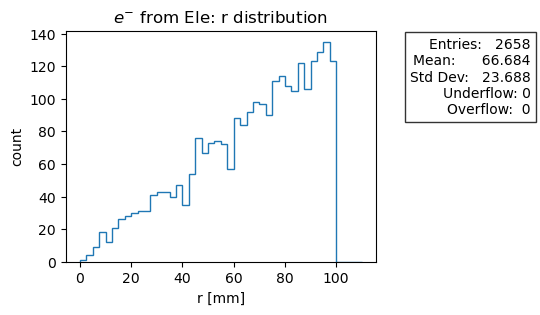

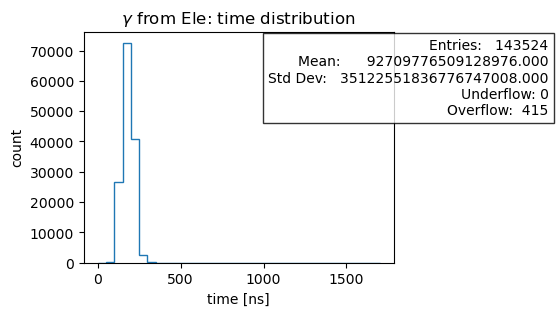

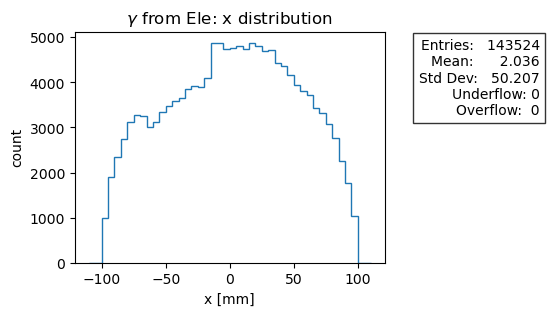

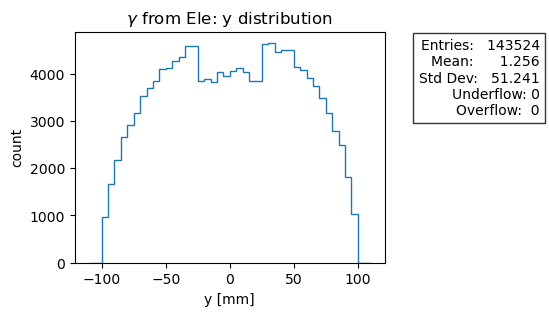

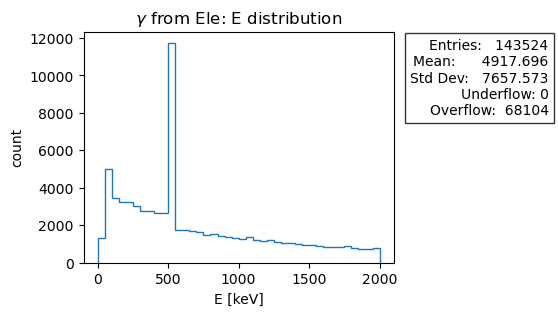

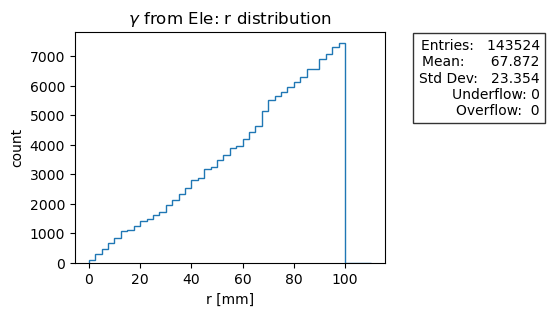

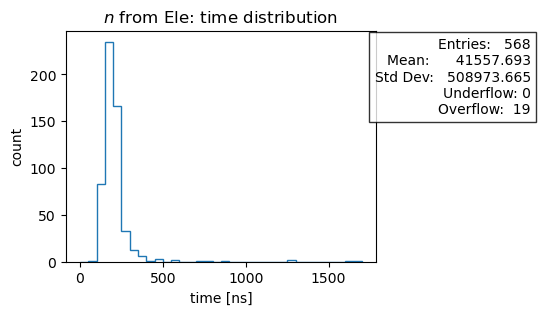

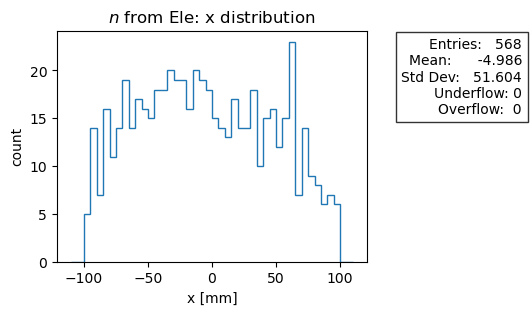

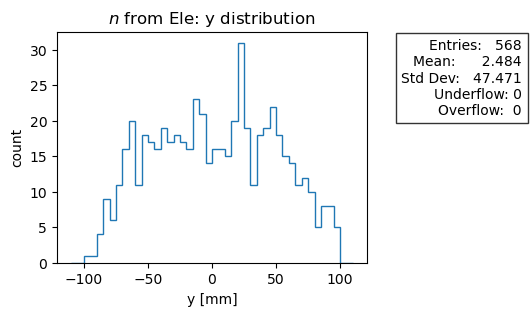

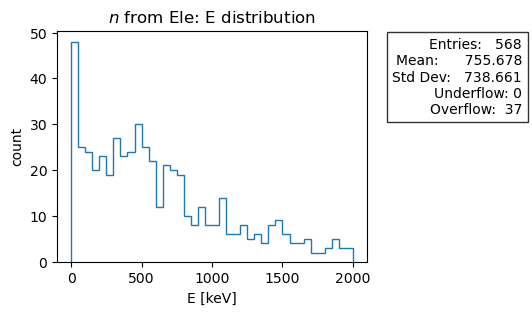

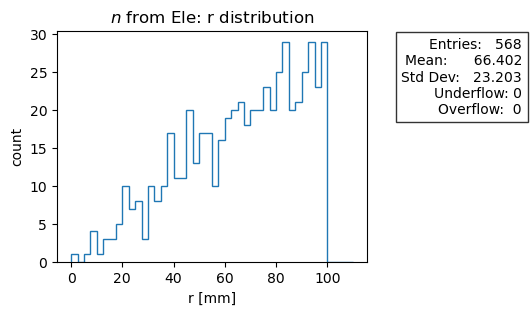

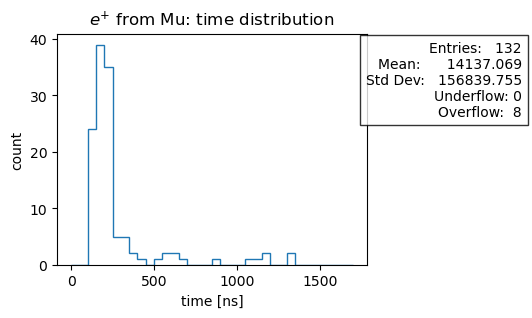

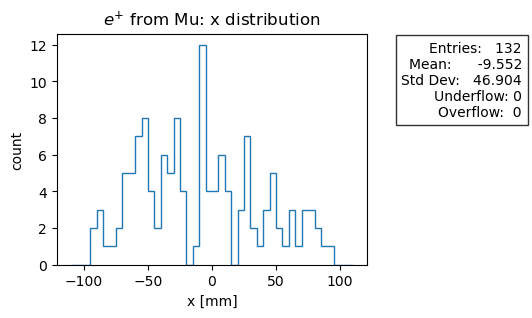

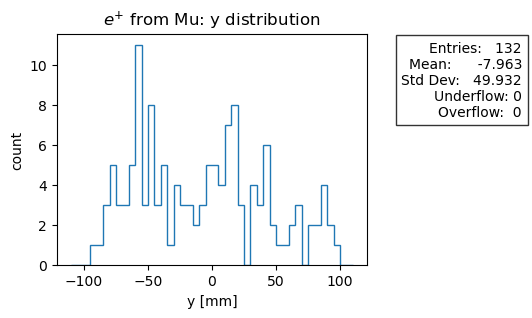

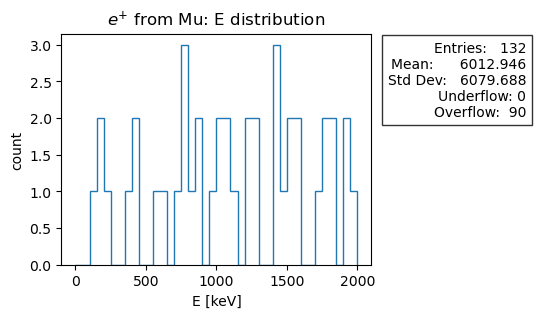

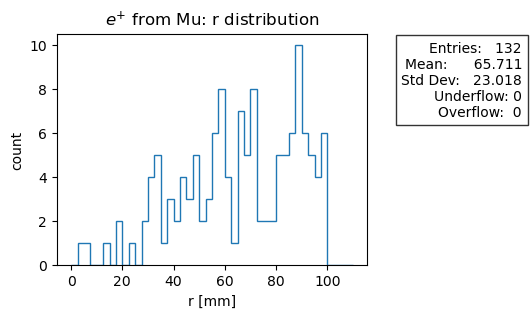

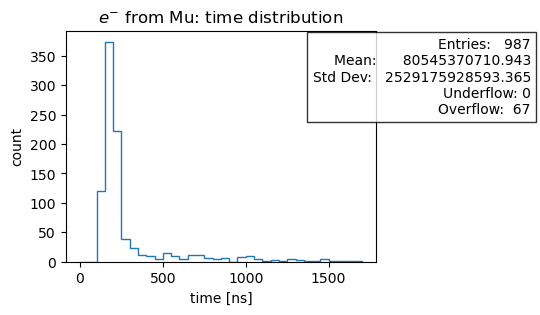

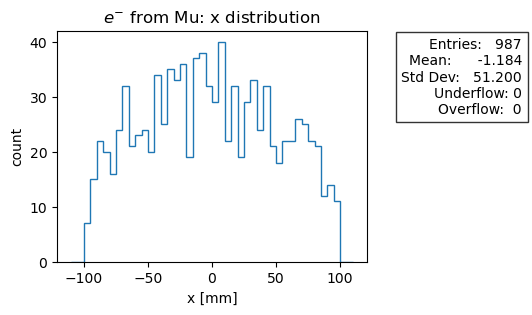

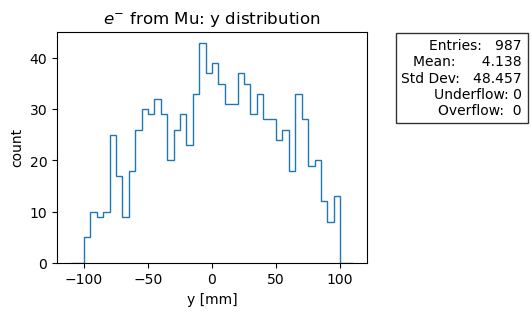

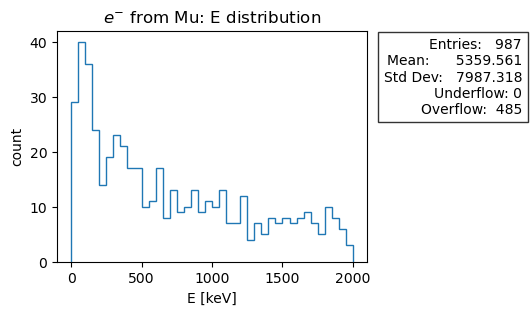

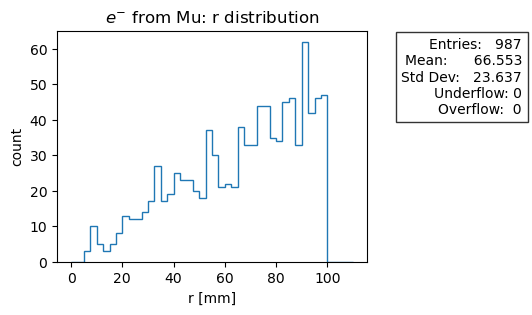

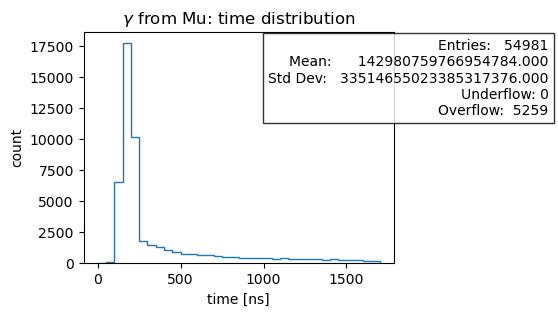

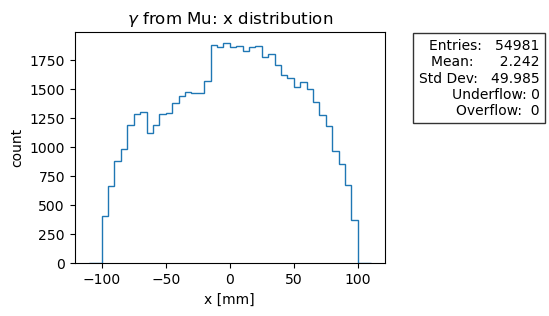

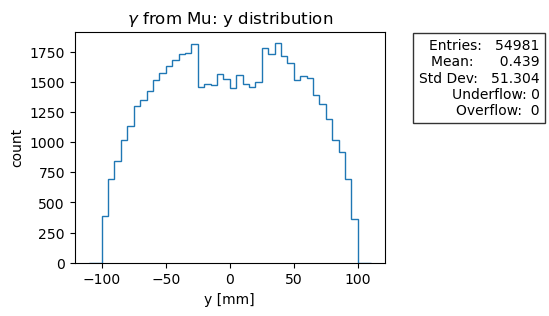

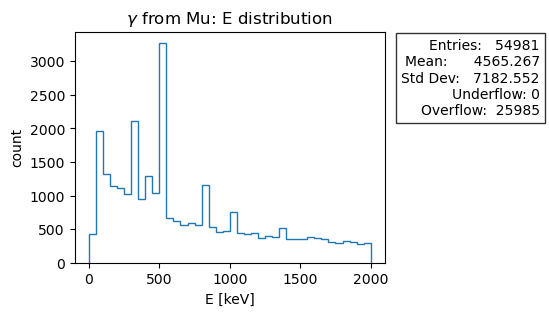

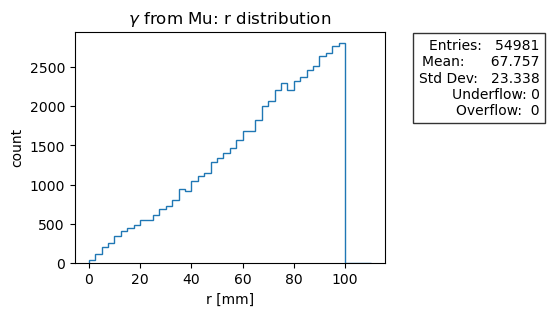

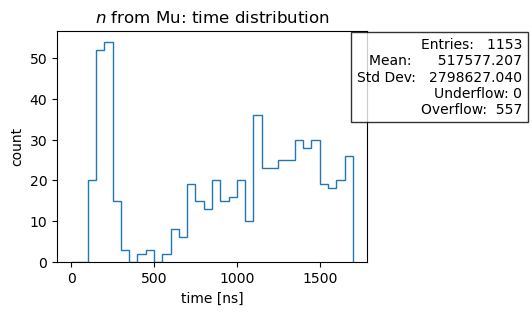

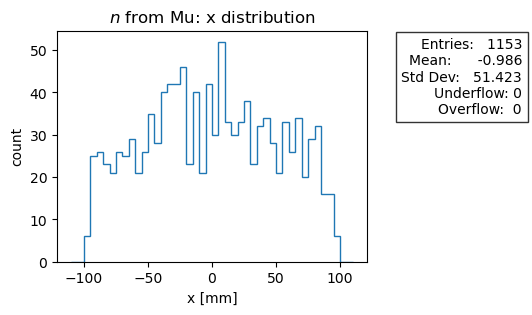

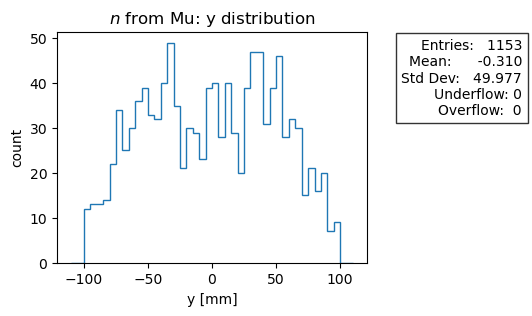

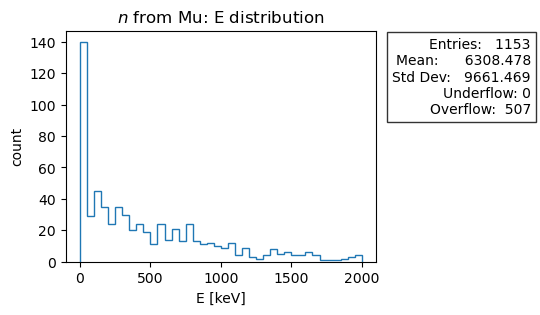

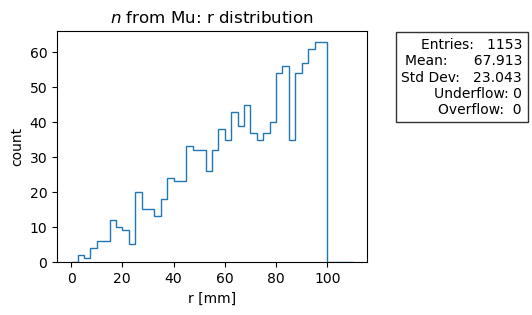

In [5]:
item_list = ['time', 'x', 'y', 'E', 'r']
title_list = [item+' distribution' for item in item_list]
xlabel_list = ['time [ns]', 'x [mm]', 'y [mm]', 'E [keV]', 'r [mm]']
ylabel_list = ['count' for item in item_list]

for tag in tags:
    print("")
    df_ = df.query("tag==@tag").reset_index()
    list_of_pdgId = np.sort(df_['pdgId'].unique())
    for pdgId in list_of_pdgId:
        mydf = df_.query("pdgId==%i"%(pdgId)).reset_index()
        group_name = pdgid_dict[pdgId]+' from '+tag+': '
        print(group_name, len(mydf))
        for index, item in enumerate(item_list):
            fig, ax = plot_utils.single_hist(mydf, item, [group_name+title_list[index], xlabel_list[index], ylabel_list[index]])
            

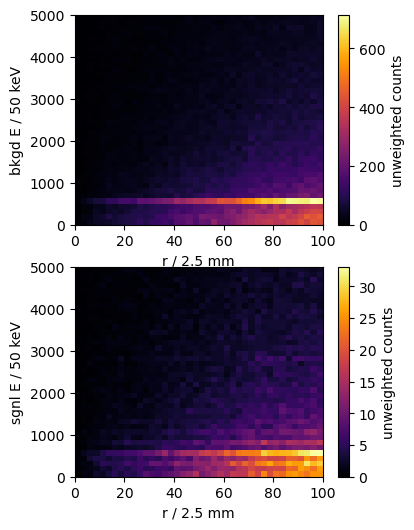

In [6]:
fig, ax = plot_utils.twod_hist(df, 'r', 'E', "")

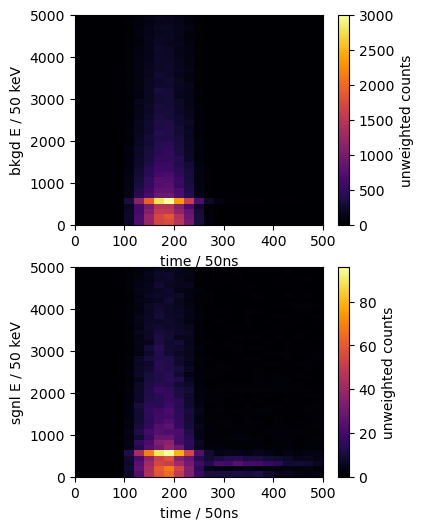

In [7]:
fig, ax = plot_utils.twod_hist(df, 'time', 'E', "")

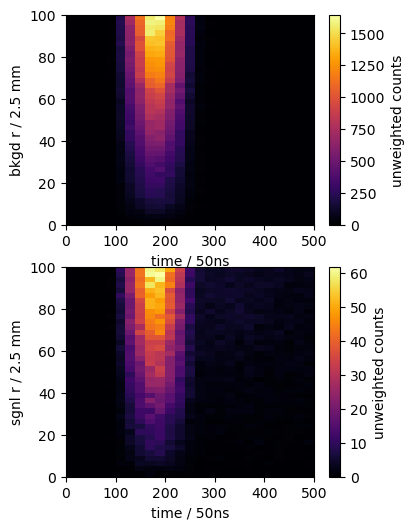

In [8]:
fig, ax = plot_utils.twod_hist(df, 'time', 'r', "")

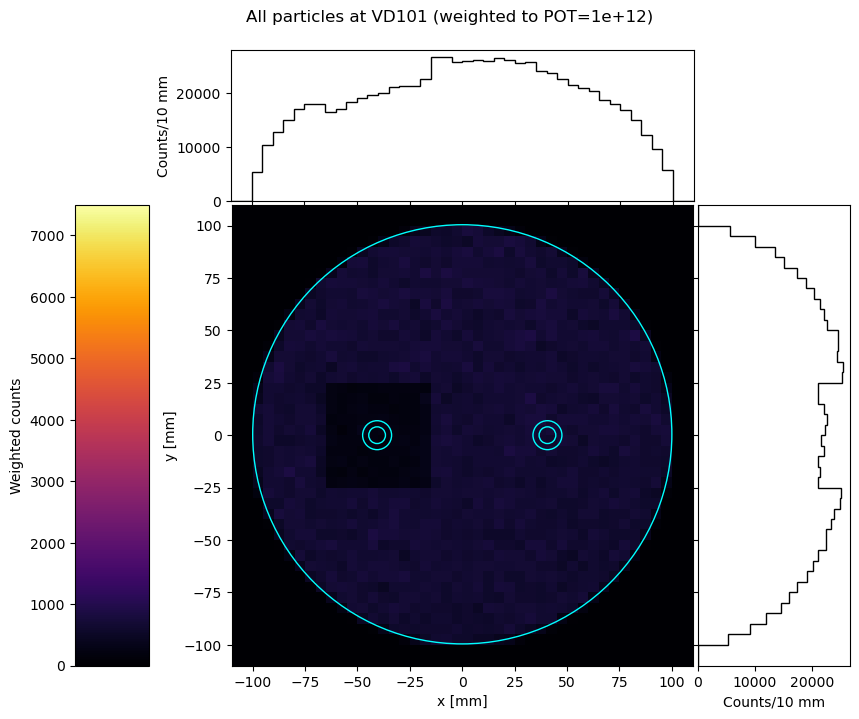

In [9]:
fig, ax2d, axX, axY = plot_utils.particle_space_dist(df, "All particles at VD101 (weighted to POT=%.0e)"%int(filepath.goal_POT), constants.XYmaxbincount)

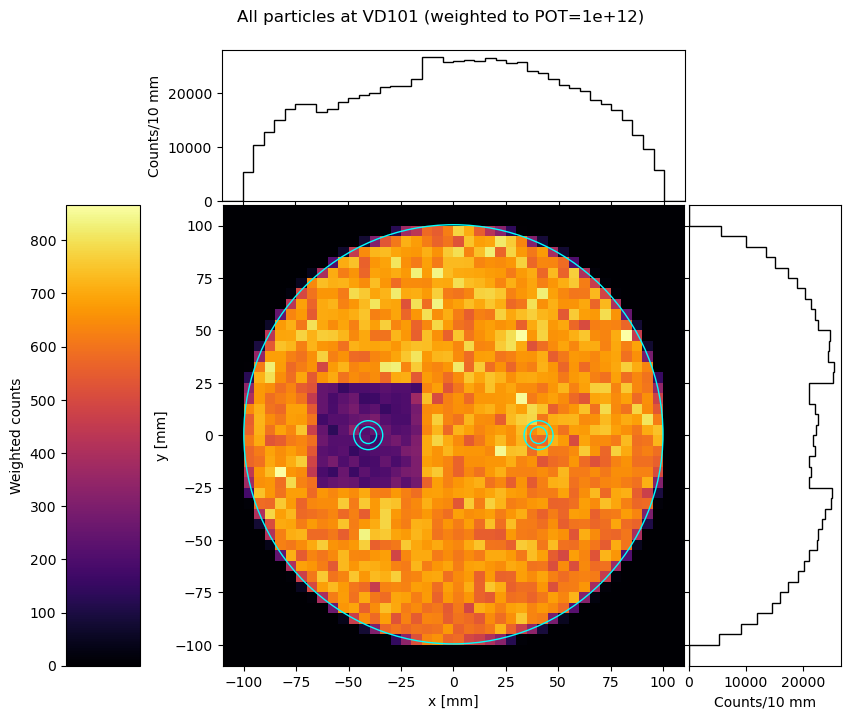

In [10]:
fig, ax2d, axX, axY = plot_utils.particle_space_dist(df, "All particles at VD101 (weighted to POT=%.0e)"%int(filepath.goal_POT))

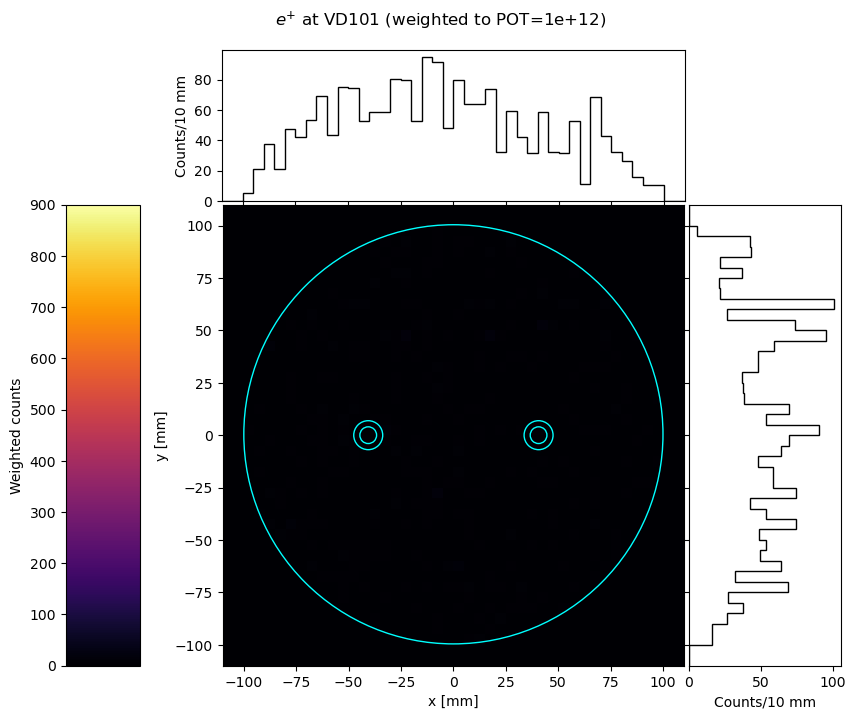

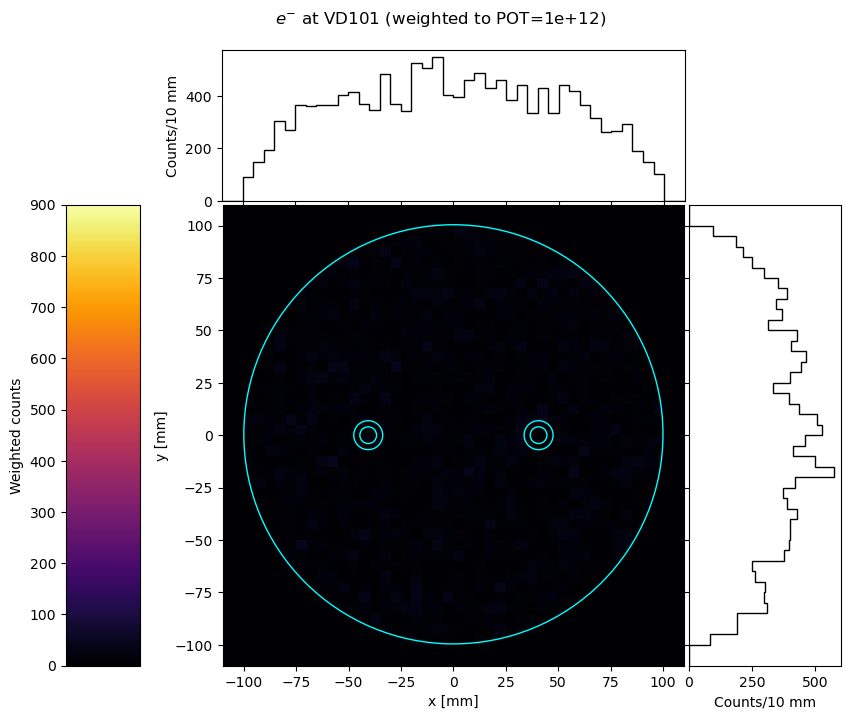

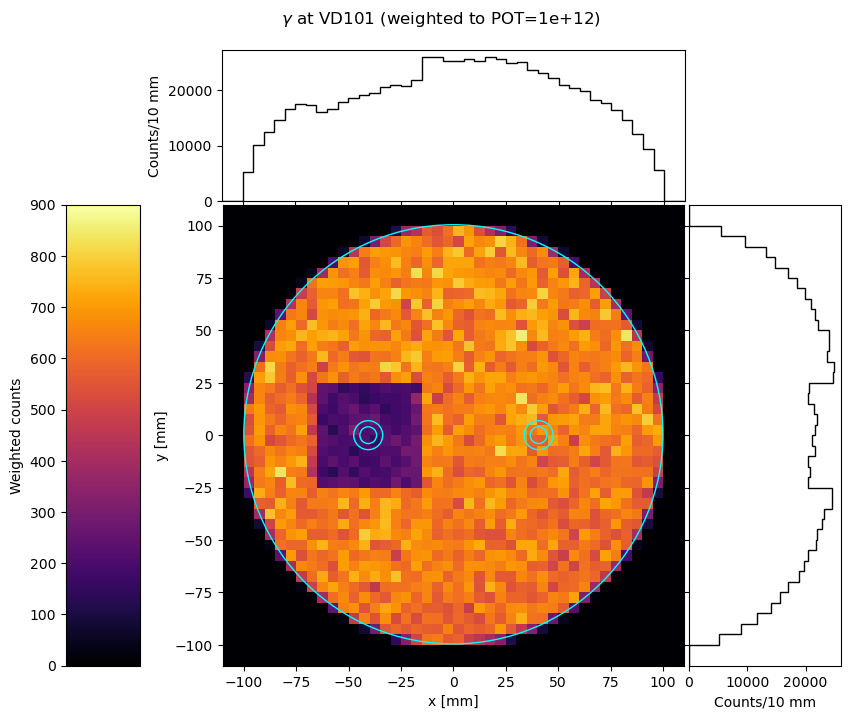

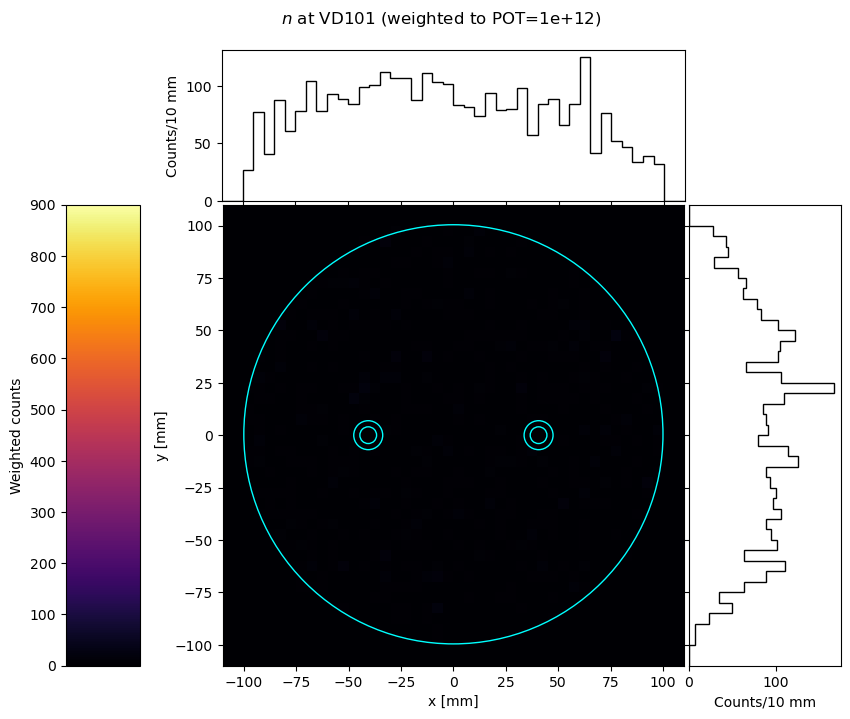

In [20]:
list_of_pdgId = np.sort(df['pdgId'].unique())
for pdgId in list_of_pdgId:
    mydf = df.query("pdgId==%i"%(pdgId)).reset_index()
    fig, ax2d, axX, axY = plot_utils.particle_space_dist(mydf, pdgid_dict[pdgId]+" at VD101 (weighted to POT=%.0e)"%int(filepath.goal_POT), 900) 
    plt.show()

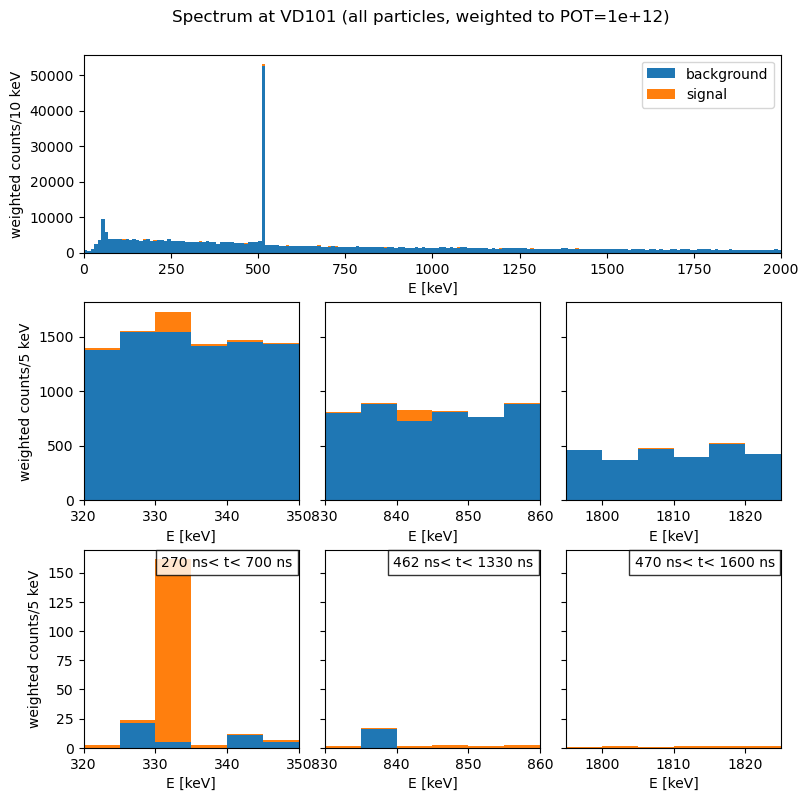

In [12]:
fig, ax = plot_utils.spectra_stacked_sgnl_bkgd(df, "Spectrum at VD101 (all particles, weighted to POT=%.0e)"%int(filepath.goal_POT))#, constants.spectramaxbincount)

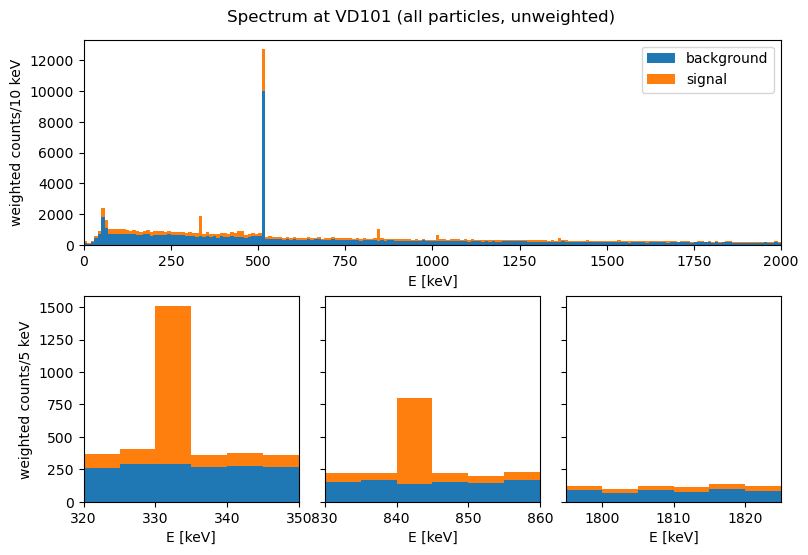

In [13]:
fig, ax = plot_utils.spectra_stacked_sgnl_bkgd(df, "Spectrum at VD101 (all particles, unweighted)", None, False)

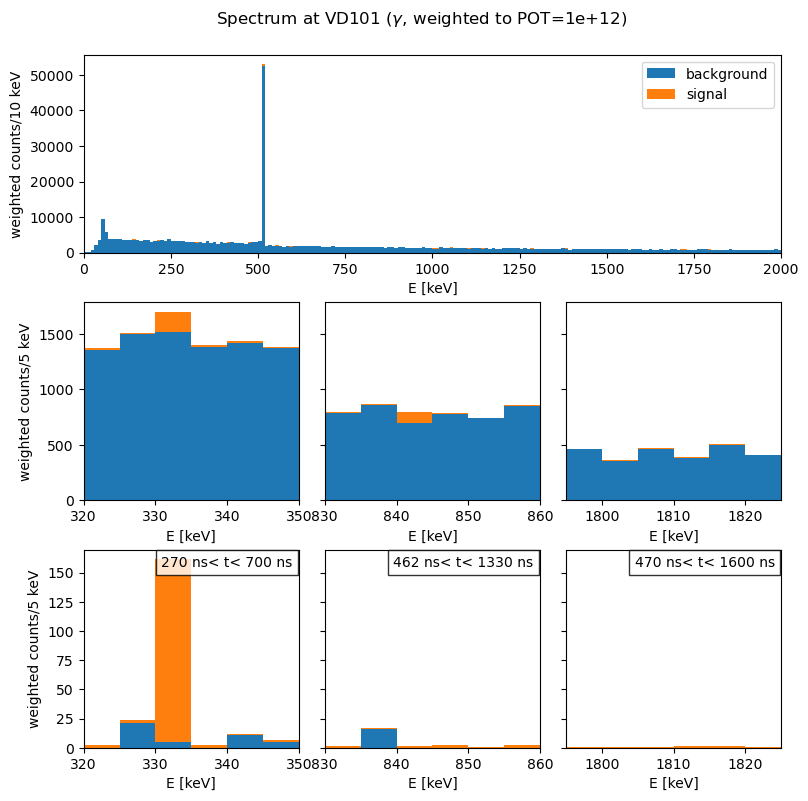

In [14]:
df_gamma = df.query("pdgId==22").reset_index()
fig, ax = plot_utils.spectra_stacked_sgnl_bkgd(df_gamma, r"Spectrum at VD101 ($\gamma$, weighted to POT=%.0e)"%int(filepath.goal_POT))#, constants.spectramaxbincount)

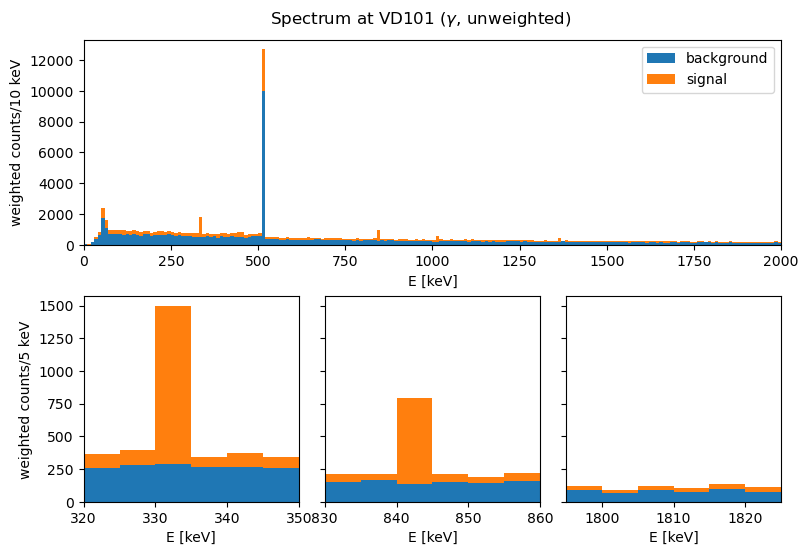

In [15]:
fig, ax = plot_utils.spectra_stacked_sgnl_bkgd(df_gamma, r"Spectrum at VD101 ($\gamma$, unweighted)", None, False)

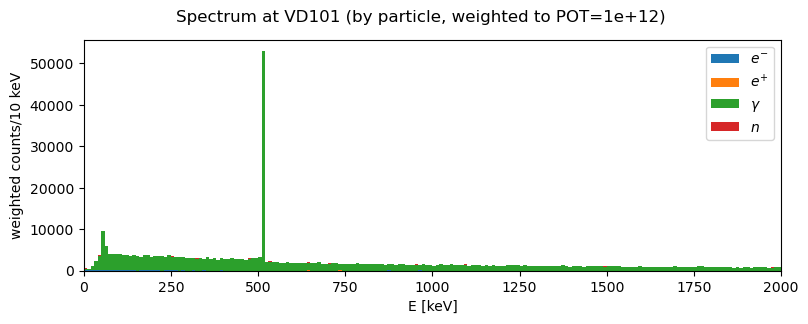

In [16]:
fig, ax = plot_utils.spectra_stacked_particle(df, "Spectrum at VD101 (by particle, weighted to POT=%.0e)"%int(filepath.goal_POT))#, constants.spectramaxbincount)

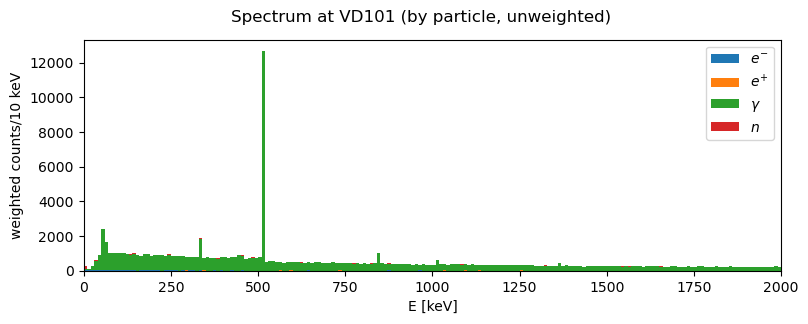

In [17]:
fig, ax = plot_utils.spectra_stacked_particle(df, "Spectrum at VD101 (by particle, unweighted)", None, False)

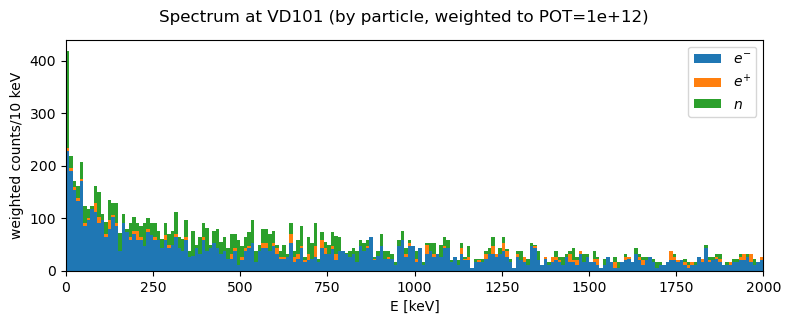

In [18]:
df_nogamma = df.query("pdgId!=22").reset_index()
fig, ax = plot_utils.spectra_stacked_particle(df_nogamma, "Spectrum at VD101 (by particle, weighted to POT=%.0e)"%int(filepath.goal_POT))#, constants.spectramaxbincount)

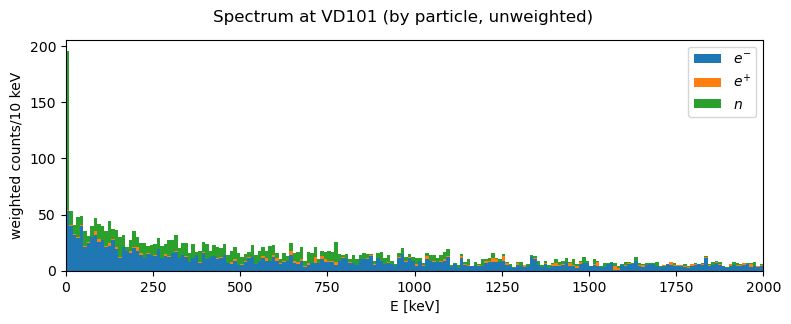

In [19]:
fig, ax = plot_utils.spectra_stacked_particle(df_nogamma, "Spectrum at VD101 (by particle, unweighted)", None, False)